# 

In [26]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

%matplotlib inline
sns.set_style('whitegrid')

print(" Cell 1: all libaries load secusesfully!")


 Cell 1: all libaries load secusesfully!


In [27]:
# Setting a random seed so that the generated random numbers remain consistent every time you run it
np.random.seed(42)
n_videos = 150  # We are generating a database of 150 videos

# 1. Generating random features using NumPy
topic_shift = np.random.choice([0, 1], size=n_videos, p=[0.6, 0.4])  
ctr = np.random.uniform(1.5, 15.0, size=n_videos)                    
retention = np.random.uniform(10.0, 65.0, size=n_videos)              
views_ratio = np.random.uniform(0.01, 0.50, size=n_videos)            

# 2. Setting up the backend mathematical pattern for Logistic Regression (Log-Odds Math)
# If Topic_Shift = 1, it increases the mathematical chance of a video dying. Higher CTR & Retention decrease it.
log_odds = (3.5 * topic_shift) - (0.4 * ctr) - (0.1 * retention) - (5.0 * views_ratio) + 2.0
probability = 1 / (1 + np.exp(-log_odds))
is_dead = np.where(probability >= 0.5, 1, 0)  # Setting the standard 0.5 decision boundary

# 3. Creating the Pandas DataFrame
df = pd.DataFrame({
    'Topic_Shift': topic_shift,
    'CTR_First_3Hrs': ctr,
    'Retention_Rate': retention,
    'Views_Sub_Ratio': views_ratio,
    'Is_Dead': is_dead
})

# 4. Intentionally adding 5% missing values (NaN) to revise data cleaning steps
for col in ['CTR_First_3Hrs', 'Retention_Rate']:
    df.loc[df.sample(frac=0.05).index, col] = np.nan

print(" Dataset successfully created with intentional missing values!")
df.head()  # Displays the first 5 rows of our generated data table


 Dataset successfully created with intentional missing values!


,Topic_Shift,CTR_First_3Hrs,Retention_Rate,Views_Sub_Ratio,Is_Dead
0,0,13.761589,12.842495,0.390802,0
1,1,4.734086,39.224505,0.283618,0
2,1,3.456081,NaN,0.217869,0
3,0,8.107612,45.058645,0.454114,0
4,0,14.806281,49.935023,0.064487,0


In [28]:
df.tail()

,Topic_Shift,CTR_First_3Hrs,Retention_Rate,Views_Sub_Ratio,Is_Dead
145,0,8.550284,62.098672,0.242241,0
146,1,11.894913,64.230059,0.337103,0
147,0,4.413584,51.435800,0.094437,0
148,0,9.909021,30.694277,0.104222,0
149,0,2.652191,14.592539,0.030026,0


In [29]:
# 1. Scan the dataset to find the exact count of missing values
print("--- Missing Values Before Imputation ---")
print(df.isnull().sum())

# 2. Compute the Median for our numerical features
ctr_median = df['CTR_First_3Hrs'].median()
retention_median = df['Retention_Rate'].median()

print(f"\nCalculated Median for CTR: {ctr_median:.2f}%")
print(f"Calculated Median for Retention: {retention_median:.2f}%")

# 3. Modern Pandas Syntax: Reassign the column directly without using inplace=True
df['CTR_First_3Hrs'] = df['CTR_First_3Hrs'].fillna(ctr_median)
df['Retention_Rate'] = df['Retention_Rate'].fillna(retention_median)

# 4. Double-check to confirm that our data contains zero missing values now
print("\n--- Missing Values After Imputation ---")
print(df.isnull().sum())
print("\n Data cleaning complete! No warnings, dataset is fully optimized.")


--- Missing Values Before Imputation ---
Topic_Shift        0
CTR_First_3Hrs     8
Retention_Rate     8
Views_Sub_Ratio    0
Is_Dead            0
dtype: int64

Calculated Median for CTR: 9.09%
Calculated Median for Retention: 38.09%

--- Missing Values After Imputation ---
Topic_Shift        0
CTR_First_3Hrs     0
Retention_Rate     0
Views_Sub_Ratio    0
Is_Dead            0
dtype: int64

 Data cleaning complete! No warnings, dataset is fully optimized.


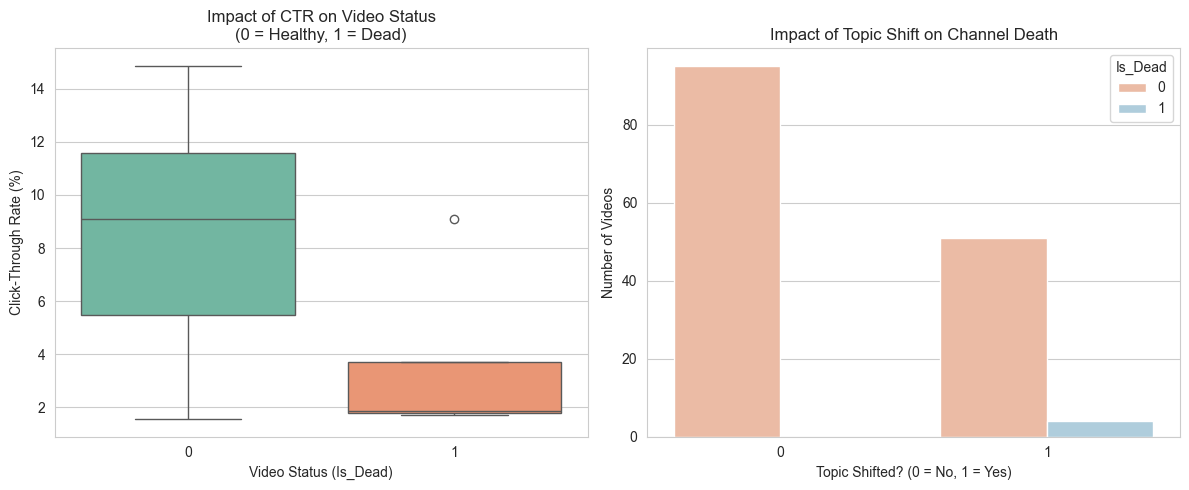

 Visual patterns successfully plotted! Analyze the graphs carefully.


In [30]:
# Create a figure canvas with a specific size
plt.figure(figsize=(12, 5))

# Plot 1: Box Plot showing how CTR affects whether a video dies (Is_Dead)
plt.subplot(1, 2, 1)
sns.boxplot(x='Is_Dead', y='CTR_First_3Hrs', data=df, hue='Is_Dead', palette='Set2', legend=False)
plt.title('Impact of CTR on Video Status\n(0 = Healthy, 1 = Dead)')
plt.xlabel('Video Status (Is_Dead)')
plt.ylabel('Click-Through Rate (%)')

# Plot 2: Count Plot showing how changing the topic increases video death rate
plt.subplot(1, 2, 2)
sns.countplot(x='Topic_Shift', hue='Is_Dead', data=df, palette='RdBu')
plt.title('Impact of Topic Shift on Channel Death')
plt.xlabel('Topic Shifted? (0 = No, 1 = Yes)')
plt.ylabel('Number of Videos')

# Adjust layout automatically so titles and labels do not overlap
plt.tight_layout()
plt.show()

print(" Visual patterns successfully plotted! Analyze the graphs carefully.")


In [31]:
df.describe

<bound method NDFrame.describe of      Topic_Shift  CTR_First_3Hrs  Retention_Rate  Views_Sub_Ratio  Is_Dead
0              0       13.761589       12.842495         0.390802        0
1              1        4.734086       39.224505         0.283618        0
2              1        3.456081       38.092700         0.217869        0
3              0        8.107612       45.058645         0.454114        0
4              0       14.806281       49.935023         0.064487        0
..           ...             ...             ...              ...      ...
145            0        8.550284       62.098672         0.242241        0
146            1       11.894913       64.230059         0.337103        0
147            0        4.413584       51.435800         0.094437        0
148            0        9.909021       30.694277         0.104222        0
149            0        2.652191       14.592539         0.030026        0

[150 rows x 5 columns]>

In [32]:
# 1. Separate independent variables (Features) and dependent variable (Target)
X = df[['Topic_Shift', 'CTR_First_3Hrs', 'Retention_Rate', 'Views_Sub_Ratio']]
y = df['Is_Dead']

# 2. Split the dataset into Training set (80%) and Testing set (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("--- Data Splitting Breakdown ---")
print(f"Total rows in original dataset : {X.shape[0]}")
print(f"Rows assigned for Training (X_train) : {X_train.shape[0]}")
print(f"Rows reserved for Testing (X_test)  : {X_test.shape[0]}")

print("\n Features separated and Train-Test split successfully executed!")

--- Data Splitting Breakdown ---
Total rows in original dataset : 150
Rows assigned for Training (X_train) : 120
Rows reserved for Testing (X_test)  : 30

 Features separated and Train-Test split successfully executed!


In [33]:
# 1. Initialize the Logistic Regression Classifier
model = LogisticRegression()

# 2. Train the model using the training features and labels
model.fit(X_train, y_train)

print(" Logistic Regression engine successfully trained on ChannelX data!")
print(f"Number of iterations taken to converge: {model.n_iter_}")


 Logistic Regression engine successfully trained on ChannelX data!
Number of iterations taken to converge: [32]


In [34]:
# 1. Extract the intercept (bias) and coefficients (weights)
intercept = model.intercept_[0]
weights = model.coef_[0]

print(f"--- ChannelX AI Internal Formula ---")
print(f"Base Intercept (c): {intercept:.4f}\n")

# 2. Map feature names directly to their calculated weights
print("--- Calculated Feature Weights ---")
for feature, weight in zip(X.columns, weights):
    print(f"Weight for {feature:15} : {weight:.4f}")

print("\n--- The Universal Truth Insights (Odds Ratios) ---")
# 3. Calculate Odds Ratio by taking the exponential of weights (e^m)
for feature, weight in zip(X.columns, weights):
    odds_ratio = np.exp(weight)
    if weight > 0:
        print(f" Each unit increase in {feature} multiplies the odds of video death by: {odds_ratio:.2f}x")
    else:
        print(f" Each unit increase in {feature} multiplies the odds of video death by: {odds_ratio:.2f}x (Decreases Risk)")


--- ChannelX AI Internal Formula ---
Base Intercept (c): 1.6194

--- Calculated Feature Weights ---
Weight for Topic_Shift     : 1.1550
Weight for CTR_First_3Hrs  : -0.5052
Weight for Retention_Rate  : -0.0839
Weight for Views_Sub_Ratio : -0.2295

--- The Universal Truth Insights (Odds Ratios) ---
 Each unit increase in Topic_Shift multiplies the odds of video death by: 3.17x
 Each unit increase in CTR_First_3Hrs multiplies the odds of video death by: 0.60x (Decreases Risk)
 Each unit increase in Retention_Rate multiplies the odds of video death by: 0.92x (Decreases Risk)
 Each unit increase in Views_Sub_Ratio multiplies the odds of video death by: 0.79x (Decreases Risk)


In [35]:
# 1. Run predictions on the hidden testing dataset
y_pred = model.predict(X_test)

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("===  CONFUSION MATRIX ===")
print(f"True Negatives  (Healthy predicted as Healthy) : {cm[0][0]}")
print(f"False Positives (Healthy predicted as Dead)    : {cm[0][1]}")
print(f"False Negatives (Dead predicted as Healthy)    : {cm[1][0]} ")
print(f"True Positives  (Dead predicted as Dead)       : {cm[1][1]}")

# 3. Generate the Detailed Classification Report
print("\n===  DETAILED CLASSIFICATION REPORT ===")
print(classification_report(y_test, y_pred))

# 4. Print Overall Accuracy Score
overall_accuracy = accuracy_score(y_test, y_pred) * 100
print(f"Overall Model Accuracy on Unseen Data: {overall_accuracy:.2f}%")


===  CONFUSION MATRIX ===
True Negatives  (Healthy predicted as Healthy) : 29
False Positives (Healthy predicted as Dead)    : 0
False Negatives (Dead predicted as Healthy)    : 0 
True Positives  (Dead predicted as Dead)       : 1

===  DETAILED CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        29
           1       1.00      1.00      1.00         1

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Overall Model Accuracy on Unseen Data: 100.00%
